# **Can Graph Structure Improve Node Classification on WikiCS?**

WikiCS is a graph dataset containing 11,701 Wikipedia articles across 10 computer science categories, connected by 431,726 hyperlinks. The task is node classification so if given an article and its connections, can we predict which of the 10 categories it belongs to?
What makes this difficult is the 10 classes overlap heavily in feature space, meaning the text content of articles alone is not enough to reliably separate categories. This raises the question can we do better by exploiting the structure of the connections between articles? Related articles are linked together so hyperlinks carry real information about topic similarity. A Graph Neural Network (GNN) is designed to exploit exactly this. Rather than classifying each article in isolation, a GNN considers what articles it links to. This project tests whether that graph structure provides meaningful signal beyond raw features alone.

Before building any models, we first explore the structure of the WikiCS dataset to understand what we are working with. We examine four things: the basic dataset statistics, the class distribution across the 10 categories, the degree distribution of nodes, and a PCA of the raw node features.
These are not just housekeeping — each observation directly motivates a modeling decision. The class imbalance affects how we evaluate our models. The hub node (degree 3,324) will become relevant when we compare GCN and GraphSAGE. And the PCA is the clearest illustration of the core challenge: the 10 classes overlap heavily in raw feature space, which is the entire motivation for using graph structure in the first place.

In [ ]:
# Installs and imports

!pip install torch_geometric

import torch
from torch_geometric.datasets import WikiCS
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from sklearn.decomposition import PCA
import networkx as nx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.9 MB/s eta 0:00:00


In [ ]:
# Load the dataset
dataset = WikiCS(root='/tmp/WikiCS')
data = dataset[0]

print(f"Number of nodes (Articles): {data.num_nodes}")
print(f"Number of edges (Hyperlinks): {data.num_edges}")
print(f"Number of features per node: {data.num_node_features}")
print(f"Number of classes (CS Fields): {dataset.num_classes}")

/tmp/ipykernel_3860/3347987541.py:2: UserWarning: The WikiCS dataset now returns an undirected graph by default. Please explicitly specify 'is_undirected=False' to restore the old behavior.
  dataset = WikiCS(root='/tmp/WikiCS')
Processing...


Number of nodes (Articles): 11701
Number of edges (Hyperlinks): 431726
Number of features per node: 300
Number of classes (CS Fields): 10


Done!


# **Class distribution**

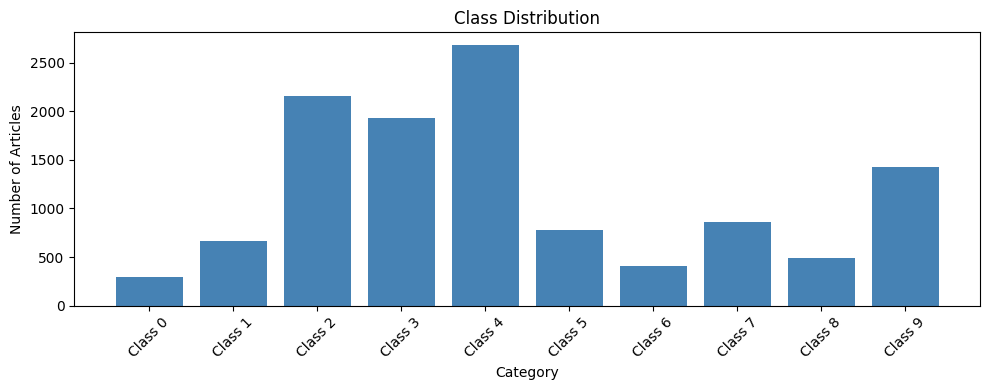

Largest class: 2679 articles
Smallest class: 295 articles


In [ ]:
# Class distribution
labels = data.y.numpy()
class_counts = Counter(labels)
classes = [f"Class {i}" for i in range(dataset.num_classes)]
counts = [class_counts[i] for i in range(dataset.num_classes)]

plt.figure(figsize=(10, 4))
plt.bar(classes, counts, color='steelblue')
plt.title('Class Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Largest class: {max(counts)} articles")
print(f"Smallest class: {min(counts)} articles")

The 10 classes are far from balanced. Class 4 has 2,679 articles while Class 0 has only 295 — nearly a 9x difference. This matters for evaluation: a model that simply predicts Class 4 for every article would achieve misleadingly high accuracy. For this reason we will use macro F1 score as our primary evaluation metric, which treats each class equally regardless of size.

# Degree **distribution**

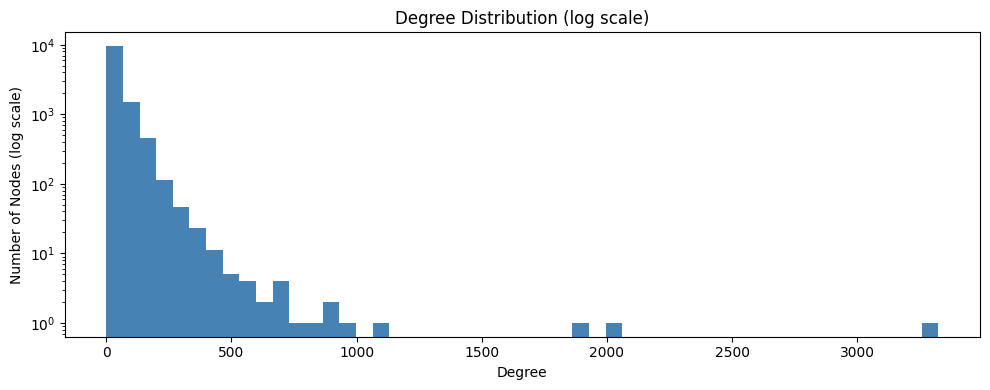

Average degree: 36.9
Median degree: 12.0
Max degree (hub node): 3324
Nodes with degree > 100: 1215


In [ ]:
# Degree distribution
edge_index = data.edge_index.numpy()
degrees = Counter(edge_index[0].tolist())
degree_values = [degrees.get(i, 0) for i in range(data.num_nodes)]

plt.figure(figsize=(10, 4))
plt.hist(degree_values, bins=50, color='steelblue', log=True)
plt.title('Degree Distribution (log scale)')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes (log scale)')
plt.tight_layout()
plt.show()

print(f"Average degree: {np.mean(degree_values):.1f}")
print(f"Median degree: {np.median(degree_values):.1f}")
print(f"Max degree (hub node): {max(degree_values)}")
print(f"Nodes with degree > 100: {sum(1 for d in degree_values if d > 100)}")

The degree distribution is heavily right-skewed. While the median degree is just 12, the average is 36.9 and the hub node has 3,324 connections. Over 1,200 nodes have degree above 100. This is important for our choice of GNN architecture — GCN aggregates all neighbors equally, meaning these hub nodes will dominate its message passing. GraphSAGE addresses this by sampling a fixed number of neighbors, which is one reason we expect it to handle this dataset better.

# **PCA**

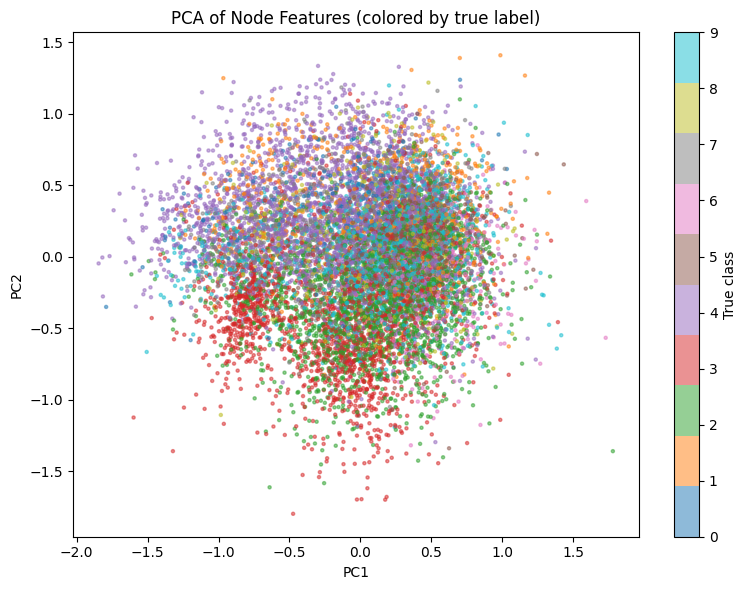

Variance explained by 2 components: 25.9%


In [ ]:
# PCA of raw node features
X = data.x.numpy()
y = data.y.numpy()

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(scatter, label='True class')
plt.title('PCA of Node Features (colored by true label)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

The PCA projects the 300-dimensional node features down to 2 dimensions, capturing 25.9% of the total variance. Even accounting for the information lost in compression, the result is clear, the 10 classes form a single dense overlapping cloud with no visible separation. There are no clean boundaries a classifier could draw using features alone.
This is the core motivation for using a Graph Neural Network. If text features cannot separate the categories, perhaps the link structure between articles can. Rather than classifying each article in isolation, a GNN incorporates information from neighboring nodes, the articles each node links to. The question is how much that graph structure actually helps. We answer this by comparing three models. First an MLP that ignores the graph entirely, a GCN that uses the full neighborhood, and GraphSAGE which samples neighborhoods to handle the hub nodes we identified earlier.

# **MLP**

Before introducing graph structure, we establish a baseline using a Multi-Layer Perceptron (MLP). The MLP takes each node's 300-dimensional feature vector as input and predicts its category using two fully connected layers. Critically, it has no awareness of edges — every article is classified in complete isolation. This tells us exactly how much signal the raw text features carry, and sets the ceiling that our graph-based models need to beat.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

# Define MLP
class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.fc1 = nn.Linear(in_channels, hidden_channels)
        self.fc2 = nn.Linear(hidden_channels, out_channels)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.fc2(x)
        return x

# Use first training split
train_mask = data.train_mask[:, 0]
val_mask = data.val_mask[:, 0]
test_mask = data.test_mask

# Initialize model
model = MLP(
    in_channels=data.num_node_features,
    hidden_channels=256,
    out_channels=dataset.num_classes
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Training loop
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x)
    loss = F.cross_entropy(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation
def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x)
        pred = out.argmax(dim=1)
        correct = pred[mask] == data.y[mask]
        acc = correct.sum().item() / mask.sum().item()
        f1 = f1_score(data.y[mask].numpy(), pred[mask].numpy(), average='macro')
    return acc, f1

# Train for 200 epochs
for epoch in range(1, 201):
    loss = train()
    if epoch % 50 == 0:
        val_acc, val_f1 = evaluate(val_mask)
        print(f"Epoch {epoch}: Loss={loss:.4f}, Val Acc={val_acc:.4f}, Val F1={val_f1:.4f}")

# Final test results
test_acc, test_f1 = evaluate(test_mask)
print(f"\nMLP Test Accuracy: {test_acc:.4f}")
print(f"MLP Test Macro F1: {test_f1:.4f}")

Epoch 50: Loss=0.2688, Val Acc=0.7451, Val F1=0.7014
Epoch 100: Loss=0.1302, Val Acc=0.7451, Val F1=0.7017
Epoch 150: Loss=0.0926, Val Acc=0.7354, Val F1=0.6876
Epoch 200: Loss=0.0806, Val Acc=0.7434, Val F1=0.6955

MLP Test Accuracy: 0.7187
MLP Test Macro F1: 0.6780


The MLP achieves a test accuracy of 71.87% and a macro F1 of 0.678. While the accuracy looks reasonable on the surface, two problems are visible. First, the model begins overfitting after around epoch 100 — the loss continues to decrease but validation accuracy plateaus and slightly drops, meaning the model is memorizing training data rather than learning generalizable patterns. Second, the gap between accuracy and macro F1 reveals that performance is uneven across classes — the model is leaning on the larger classes like Class 4 and struggling with smaller ones. This is exactly why we use macro F1 as our primary metric.
This gives us our baseline: 71.87% accuracy, 0.678 macro F1. These are the numbers our graph-based models need to beat. If GCN and GraphSAGE cannot improve on an MLP that ignores the graph entirely, then graph structure is not helping. If they do improve, we have direct evidence that hyperlinks between articles carry meaningful information beyond what the text features provide alone.

# **GCN**

The MLP established that raw features alone achieve 71.87% accuracy. We now introduce our first graph-based model — a Graph Convolutional Network (GCN). Unlike the MLP, the GCN aggregates feature information from each node's neighbors during each layer. In other words, an article's classification is now influenced not just by its own text features, but by the features of every article it links to. This is where the edge structure of WikiCS becomes useful.
However, GCN has a known weakness on graphs like WikiCS: it aggregates all neighbors equally. Recall from our EDA that the hub node has 3,324 connections. In GCN, that hub influences every node it connects to with equal weight regardless of relevance. We expect this to limit GCN's performance, which motivates GraphSAGE in the next section.

In [ ]:
from torch_geometric.nn import GCNConv

# Define GCN
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Initialize model
model_gcn = GCN(
    in_channels=data.num_node_features,
    hidden_channels=256,
    out_channels=dataset.num_classes
)

optimizer_gcn = torch.optim.Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)

# Training loop
def train_gcn():
    model_gcn.train()
    optimizer_gcn.zero_grad()
    out = model_gcn(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer_gcn.step()
    return loss.item()

# Evaluation
def evaluate_gcn(mask):
    model_gcn.eval()
    with torch.no_grad():
        out = model_gcn(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct = pred[mask] == data.y[mask]
        acc = correct.sum().item() / mask.sum().item()
        f1 = f1_score(data.y[mask].numpy(), pred[mask].numpy(), average='macro')
    return acc, f1

# Train for 200 epochs
for epoch in range(1, 201):
    loss = train_gcn()
    if epoch % 50 == 0:
        val_acc, val_f1 = evaluate_gcn(val_mask)
        print(f"Epoch {epoch}: Loss={loss:.4f}, Val Acc={val_acc:.4f}, Val F1={val_f1:.4f}")

# Final test results
test_acc_gcn, test_f1_gcn = evaluate_gcn(test_mask)
print(f"\nGCN Test Accuracy: {test_acc_gcn:.4f}")
print(f"GCN Test Macro F1: {test_f1_gcn:.4f}")

Epoch 50: Loss=0.4865, Val Acc=0.8135, Val F1=0.7783
Epoch 100: Loss=0.4070, Val Acc=0.8185, Val F1=0.7821
Epoch 150: Loss=0.3666, Val Acc=0.8236, Val F1=0.7929
Epoch 200: Loss=0.3687, Val Acc=0.8214, Val F1=0.7904

GCN Test Accuracy: 0.7932
GCN Test Macro F1: 0.7678


Adding graph structure produces a substantial improvement over the MLP baseline. GCN achieves 79.32% test accuracy and a macro F1 of 0.768, compared to 71.87% and 0.678 for the MLP — an improvement of roughly 8 percentage points on both metrics. This is direct evidence that the hyperlink structure between Wikipedia articles carries meaningful information beyond what text features provide alone.
Notably, the GCN's training loss remains higher than the MLP's, but this is not a weakness — it reflects that the GCN is not overfitting to the training data the way the MLP was. Validation accuracy continues improving through epoch 150, suggesting the model is genuinely learning rather than memorizing.
However, recall that GCN aggregates all neighbors equally. With hub nodes containing thousands of connections, some nodes are being heavily influenced by articles that may not be topically relevant. GraphSAGE addresses this directly by sampling a fixed number of neighbors, which we test next.

# **GraphSage**

GCN improved substantially over the MLP, confirming that graph structure helps. However, GCN's equal weighting of all neighbors is a potential weakness on WikiCS given the heavily skewed degree distribution we observed in the EDA. GraphSAGE addresses this by sampling a fixed number of neighbors per node rather than using all of them, and by concatenating a node's own features with the aggregated neighborhood rather than averaging everything together. This preserves each node's individual identity more strongly and reduces the influence of hub nodes.

In [ ]:
from torch_geometric.nn import SAGEConv

# Define GraphSAGE
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Initialize model
model_sage = GraphSAGE(
    in_channels=data.num_node_features,
    hidden_channels=256,
    out_channels=dataset.num_classes
)

optimizer_sage = torch.optim.Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)

# Training loop
def train_sage():
    model_sage.train()
    optimizer_sage.zero_grad()
    out = model_sage(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer_sage.step()
    return loss.item()

# Evaluation
def evaluate_sage(mask):
    model_sage.eval()
    with torch.no_grad():
        out = model_sage(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct = pred[mask] == data.y[mask]
        acc = correct.sum().item() / mask.sum().item()
        f1 = f1_score(data.y[mask].numpy(), pred[mask].numpy(), average='macro')
    return acc, f1

# Train for 200 epochs
for epoch in range(1, 201):
    loss = train_sage()
    if epoch % 50 == 0:
        val_acc, val_f1 = evaluate_sage(val_mask)
        print(f"Epoch {epoch}: Loss={loss:.4f}, Val Acc={val_acc:.4f}, Val F1={val_f1:.4f}")

# Final test results
test_acc_sage, test_f1_sage = evaluate_sage(test_mask)
print(f"\nGraphSAGE Test Accuracy: {test_acc_sage:.4f}")
print(f"GraphSAGE Test Macro F1: {test_f1_sage:.4f}")

Epoch 50: Loss=0.2005, Val Acc=0.8157, Val F1=0.7751
Epoch 100: Loss=0.0995, Val Acc=0.8033, Val F1=0.7651
Epoch 150: Loss=0.0753, Val Acc=0.7965, Val F1=0.7549
Epoch 200: Loss=0.0666, Val Acc=0.8067, Val F1=0.7690

GraphSAGE Test Accuracy: 0.7872
GraphSAGE Test Macro F1: 0.7589


GraphSAGE achieves 78.72% test accuracy and a macro F1 of 0.759 — marginally below GCN's 79.32% and 0.768. This was unexpected. The hypothesis going in was that GCN's equal weighting of all neighbors would hurt it on WikiCS given the extreme hub nodes in the degree distribution. GraphSAGE's neighborhood sampling was expected to reduce that noise.
However, the results suggest the opposite is true on this dataset. However, WikiCS has a homophily ratio of 0.65 — meaning 65% of edges connect articles within the same category. Even the hub node's thousands of connections are predominantly same-category links. Rather than introducing noise, those hub connections are consistently reinforcing the correct label. When GraphSAGE samples only a subset of neighbors, it risks discarding some of that useful same-category signal by chance, which likely explains the slightly weaker performance.
Additionally, GraphSAGE shows the same overfitting pattern as the MLP — validation accuracy peaks around epoch 50 and degrades as training loss continues to fall. GCN remained more stable throughout training.
This is an important finding: the right architecture depends on the graph's properties. On a high-homophily graph like WikiCS, using the full neighborhood is an advantage, not a liability.

# **Comparison and Analysis**

In [ ]:
# Summary comparison table
from sklearn.metrics import classification_report

print("=" * 50)
print(f"{'Model':<15} {'Accuracy':>10} {'Macro F1':>10}")
print("=" * 50)
print(f"{'MLP':<15} {0.7187:>10.4f} {0.6780:>10.4f}")
print(f"{'GCN':<15} {test_acc_gcn:>10.4f} {test_f1_gcn:>10.4f}")
print(f"{'GraphSAGE':<15} {test_acc_sage:>10.4f} {test_f1_sage:>10.4f}")
print("=" * 50)

Model             Accuracy   Macro F1
MLP                 0.7187     0.6780
GCN                 0.7932     0.7678
GraphSAGE           0.7872     0.7589


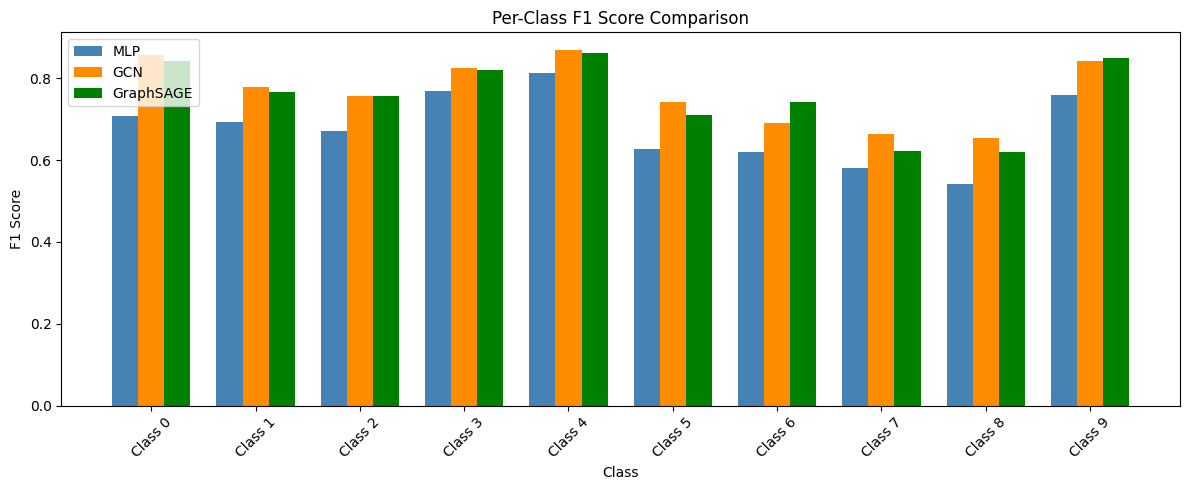

           MLP    GCN  GraphSAGE  GCN vs MLP
Class 0  0.708  0.857      0.842       0.149
Class 1  0.693  0.779      0.766       0.086
Class 2  0.671  0.756      0.756       0.084
Class 3  0.769  0.825      0.820       0.056
Class 4  0.814  0.869      0.862       0.055
Class 5  0.626  0.741      0.711       0.115
Class 6  0.618  0.691      0.741       0.072
Class 7  0.581  0.664      0.623       0.084
Class 8  0.540  0.654      0.619       0.113
Class 9  0.759  0.843      0.849       0.083


In [ ]:
# Per-class F1 comparison across all three models
from sklearn.metrics import classification_report
import pandas as pd

# Get predictions from all three models
model.eval()
model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    pred_mlp = model(data.x).argmax(dim=1)
    pred_gcn = model_gcn(data.x, data.edge_index).argmax(dim=1)
    pred_sage = model_sage(data.x, data.edge_index).argmax(dim=1)

# Get per-class F1 for each model on test set
f1_mlp = f1_score(data.y[test_mask].numpy(), pred_mlp[test_mask].numpy(), average=None)
f1_gcn = f1_score(data.y[test_mask].numpy(), pred_gcn[test_mask].numpy(), average=None)
f1_sage = f1_score(data.y[test_mask].numpy(), pred_sage[test_mask].numpy(), average=None)

# Plot
x = np.arange(dataset.num_classes)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, f1_mlp, width, label='MLP', color='steelblue')
ax.bar(x, f1_gcn, width, label='GCN', color='darkorange')
ax.bar(x + width, f1_sage, width, label='GraphSAGE', color='green')

ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels([f'Class {i}' for i in range(dataset.num_classes)], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Print the numbers
df = pd.DataFrame({'MLP': f1_mlp, 'GCN': f1_gcn, 'GraphSAGE': f1_sage},
                   index=[f'Class {i}' for i in range(dataset.num_classes)])
df['GCN vs MLP'] = df['GCN'] - df['MLP']
print(df.round(3))

The per-class analysis reveals that the classes that benefited most from graph structure — Class 0 (+0.149), Class 5 (+0.115), and Class 8 (+0.113) — are among the smallest in the dataset. With fewer training examples, these classes have less feature-based signal to learn from, so neighborhood information from connected articles provides a critical boost. The graph structure compensates for what the limited training data cannot provide alone.
Classes 3 and 4 showed the smallest improvement from adding graph structure, but this is because they were already the strongest performers under the MLP. Their text features are distinctive enough that the graph adds relatively little on top.
Classes 7 and 8 remain the hardest across all three models despite graph structure helping. This likely reflects genuine topic ambiguity — these categories probably share vocabulary and hyperlinks with neighboring topics, meaning neither their text features nor their connections cleanly distinguish them. This is consistent with the PCA, where those classes sit deepest in the overlapping central region.

# **Conclusion**

This project set out to answer a single question: does incorporating graph structure improve node classification on WikiCS compared to using node features alone?
The answer is clearly yes. The MLP, which classified each article using only its 300-dimensional text features, achieved 71.87% accuracy and a macro F1 of 0.678. Adding graph structure through GCN pushed that to 79.32% accuracy and 0.768 F1 — an improvement of roughly 8 percentage points on both metrics. The hyperlinks between Wikipedia articles carry real information about category membership that text features alone cannot capture.
The comparison between GCN and GraphSAGE produced an unexpected but informative finding. GraphSAGE, which samples neighborhoods rather than aggregating all neighbors equally, performed marginally worse than GCN (78.72% accuracy, 0.759 F1). The likely explanation connects back to the dataset's homophily ratio of 0.65 — because the majority of edges connect same-category articles, even hub node connections are mostly useful signal rather than noise. GraphSAGE's sampling discards some of that signal by chance, which hurts rather than helps on this particular graph.
This highlights an important limitation: architecture choice depends on the properties of the graph. GCN's full neighborhood aggregation is an advantage on high-homophily graphs like WikiCS, but may not generalize to graphs with lower homophily or more noisy connections. GraphSAGE's performance could likely be improved with tuned neighbor sampling sizes — a direction for future work.
Finally, the per-class analysis showed that smaller, underrepresented classes benefited most from graph structure, while Classes 7 and 8 remained difficult across all models, likely due to genuine topic ambiguity and shared vocabulary with neighboring categories.

## Resources & Collaboration

1. **Collaborators:** None

2. **Web Sources:**
   - https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.WikiCS.html
   - https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html

3. **AI Tools:**
   - ChatGPT: used to help format markdown tables and assist with PyTorch Geometric dataset loading
   - Google Gemini: used to perform initial EDA on the WikiCS dataset as well as implementing each model